<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Sesión Sincrónica — Semana 2

Esta sesión es el **puente** entre lo que vimos la semana pasada (PCA), lo de esta semana y el **Taller 2**, en el que van a construir y evaluar un sistema sencillo de reconocimiento facial con *eigenfaces*.

No voy a cubrir PCA ni SVD de manera exhaustiva; para ello están las actividades de la plataforma. En esta clase voy a utilizar las caras de Olivetti como hilo conductor y ejemplo de los conceptos teóricos.


**NO** es necesario editar este archivo ni hacer una entrega. Las celdas de código (`en gris`) son ejecutables y pueden modificarlas libremente.

In [1]:
# Librerías de la sesión
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# Figuras pensadas para proyectar: más resolución y tipografía más grande
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12

# 1. Repaso de PCA




## Pregunta 1

> Tenemos $p$ variables originales y queremos representar los datos usando solo $K < p$ dimensiones.
> **¿Qué hace PCA?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<ul>
<li>Busca <b>nuevas direcciones</b> en el espacio de las variables, que son <b>combinaciones lineales</b> de las originales.</li>
<li>Las elige de forma que la <b>varianza</b> de los datos proyectados sea máxima, y que sean <b>ortogonales</b> entre sí.</li>
<li>Proyecta los datos sobre las primeras K  direcciones: eso es la <b>reducción de dimensión</b>.</li>
</ul>
</details>

## Pregunta 2

> **¿Un componente principal es una de las variables originales?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p><b>No.</b> Es una combinación lineal de <i>todas</i> las variables originales. Por eso un componente no
tiene, en general, una interpretación tan limpia como una variable medida: es una mezcla.</p>
</details>

## Pregunta 3

> **¿Por qué PC1 aparece antes que PC2?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p>Porque PC1 es la dirección que captura la <b>mayor variabilidad</b>. PC2 captura la mayor variabilidad
<i>restante</i>, sujeta a ser ortogonal a PC1; PC3 la que queda tras esas dos, y así sucesivamente. El orden
no es arbitrario, está dado por el método.</p>
</details>

Entonces, cuando escribimos el primer componente como

$$
\underbrace{\text{PC}_1 = v_{11}X_1 + v_{12}X_2 + \cdots + v_{1p}X_p}_{\text{combinación lineal de las variables originales}}
$$

esos pesos $v_{1j}$ son **las entradas de un vector**: exactamente las de la primera dirección $v_1$, las del primer autovector, que esta asociado al autovalor mas grande.

# 2. Introducción a *eigenfaces* con las caras Olivetti


En esta clase voy a utilizar la base de rostros de **Olivetti** (400 fotos de 40 personas, tomadas en condiciones controladas de laboratorio) para ilustrar la teoría de la semana y para ayudarlos con el Taller.

**Ojo:** el Taller 2 usa otra base, **LFW** (fotos de prensa, mucho más difíciles). Aquí aprendemos el **procedimiento** y la **interpretación**.

Obtengamos los datos y veamos las dimensiones:

In [18]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces(data_home='data')

n_samples, h, w = olivetti.images.shape



In [19]:
print('imágenes:', n_samples, '| alto:', h, '| ancho:', w)

imágenes: 400 | alto: 64 | ancho: 64


In [20]:
print('personas distintas:', len(np.unique(olivetti.target)))

personas distintas: 40


Hacemos una función sencilla que nos permite graficar cualquier rostro:

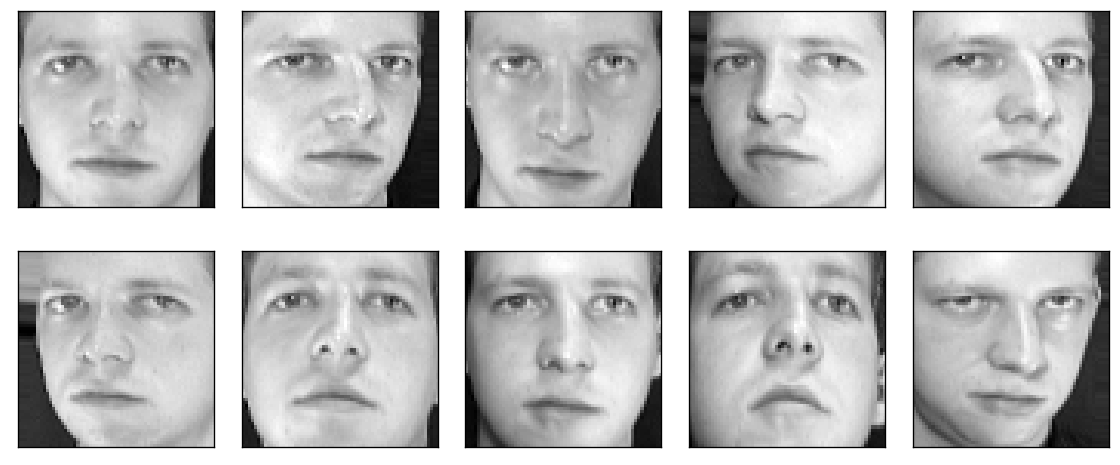

In [21]:
def mostrar_caras(imagenes, titulos=None, n_col=5, alto_panel=2.2, ancho_panel=1.9,
                  cmap='gray', vmin=None, vmax=None):
    # imagenes: array (n, h*w) o (n, h, w). Dibuja una grilla de caras.
    imagenes = np.asarray(imagenes)
    n = len(imagenes)
    n_row = int(np.ceil(n / n_col))
    plt.figure(figsize=(ancho_panel * n_col, alto_panel * n_row))
    for i in range(n):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(imagenes[i].reshape(h, w), cmap=cmap, vmin=vmin, vmax=vmax)
        if titulos is not None:
            plt.title(titulos[i], fontsize=12)
        plt.xticks(())
        plt.yticks(())
    plt.tight_layout()
    plt.show()


mostrar_caras(olivetti.images[:10], n_col=5)

y la segunda

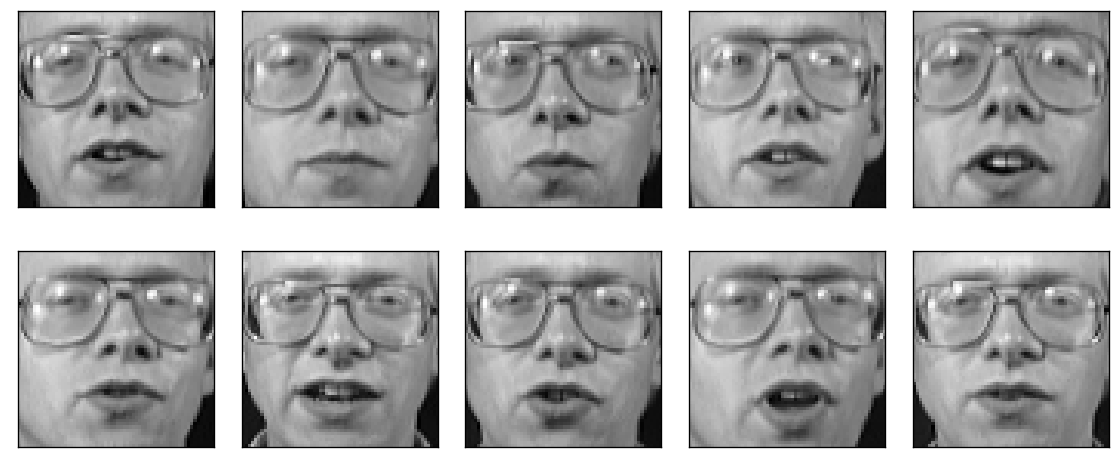

In [24]:
mostrar_caras(olivetti.images[10:20], n_col=5)

Olivetti trae 10 fotos por individuo, y estas son las 10 de la primera persona y de la segunda. Cambian el gesto, la
inclinación de la cabeza, las gafas y la iluminación: aunque **es siempre la misma persona**, los píxeles
de una foto a otra son muy distintos.

> **¿Qué le exige eso a un sistema de reconocimiento facial?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p>Que diga "es la misma persona" <i>a pesar</i> de que los números cambian. El sistema no puede memorizar
píxeles: tiene que capturar algo que sobreviva a los cambios de gesto, pose e iluminación.</p>
<p>Y en `LFW (fotos de prensa, tomadas en la calle, con poses y luces arbitrarias)` esa variación es mucho
mayor que aquí. Graficarlas, mirarlas con cuidado y estudiarlas es el primer paso del taller.</p>
</details>

## Construir la matriz $X$

Para simplificar la tarea y utilizar álgebra lineal fácilmente, lo que haremos es "aplanar" las imágenes de forma tal que:

- **una fila = una imagen**
- **una columna = un píxel**

es decir, "aplanamos" cada imagen de $h \times w$ en un vector de $p = h \times w$ números.

In [4]:
X = olivetti.data                 # ya viene aplanada: (n imágenes) x (p píxeles)
y = olivetti.target               # identidad de la persona (0 a 39)

n, p = X.shape
print('X.shape =', X.shape, ' -> ', n, 'imágenes x', p, 'píxeles')
print('p = h * w =', h, '*', w, '=', h * w)
print('rango de intensidades:', X.min(), 'a', X.max())

X.shape = (400, 4096)  ->  400 imágenes x 4096 píxeles
p = h * w = 64 * 64 = 4096
rango de intensidades: 0.0 a 1.0


## Una cara como vector

Cada imagen de Olivetti tiene $64\times64=4096$ píxeles. Al aplanarla obtenemos

$$
x=[x_1,x_2,\ldots,x_{4096}]\in\mathbb{R}^{4096}.
$$

Por eso la matriz que acabamos de construir tiene **una fila por cara** y **una columna por píxel**.

La representación píxel a píxel es exacta, pero usa 4096 números por imagen. La pregunta de PCA será:

> **¿Podemos describir estas caras usando pocas imágenes-patrón globales, en vez de miles de píxeles por separado?**

Primero necesitamos separar lo que todas las caras comparten de aquello en lo que varían.

## Una imagen representada como una base de píxeles

Ya tenemos cada cara como un vector de $p$ números, donde cada $x_j$ es la intensidad del píxel $j$. La pregunta ahora es con qué **piezas** la describimos.

La idea importante es que una **base** es un conjunto fijo de piezas que usamos para describir todas nuestras imágenes.

La base más simple es la **base de píxeles**:

$$
e_1, e_2, \ldots, e_p.
$$

Cada $e_j$ enciende un solo píxel y deja todos los demás en cero.

Por ejemplo, si nuestras imágenes tuvieran solo cuatro píxeles:

$$
e_1 =
\begin{bmatrix}
1\\
0\\
0\\
0
\end{bmatrix},
\qquad
e_2 =
\begin{bmatrix}
0\\
1\\
0\\
0
\end{bmatrix},
\qquad
e_3 =
\begin{bmatrix}
0\\
0\\
1\\
0
\end{bmatrix},
\qquad
e_4 =
\begin{bmatrix}
0\\
0\\
0\\
1
\end{bmatrix}.
$$

Estas cuatro piezas son las mismas para todas las imágenes.

Por ejemplo, una imagen podría ser

$$
x^{(1)} =
\begin{bmatrix}
0.2\\
0.8\\
0.4\\
0.1
\end{bmatrix}.
$$

Entonces podemos escribirla como

$$
x^{(1)} = 0.2e_1 + 0.8e_2 + 0.4e_3 + 0.1e_4.
$$

Otra imagen podría ser

$$
x^{(2)} =
\begin{bmatrix}
0.7\\
0.1\\
0.3\\
0.9
\end{bmatrix},
$$

y usamos exactamente las mismas piezas:

$$
x^{(2)} = 0.7e_1 + 0.1e_2 + 0.3e_3 + 0.9e_4.
$$

La base no cambia de una imagen a otra. Lo que cambia son los números que multiplican a cada pieza.

En general,

$$
x = x_1e_1 + x_2e_2 + \cdots + x_pe_p.
$$

Por tanto, una base responde a la pregunta:

> **¿Cuáles son las piezas comunes con las que voy a describir todas mis imágenes?**

En la base de píxeles, esas piezas son simplemente:

- píxel 1,
- píxel 2,
- píxel 3,
- $\ldots$
- píxel $p$.

Esta representación permite reconstruir exactamente cualquier imagen de $p$ píxeles.

El problema aparece cuando queremos describir una imagen usando **pocas piezas**.

Pensemos en una imagen de $8 \times 8$ píxeles. Entonces

$$
p = 64.
$$

Su representación exacta es

$$
x = x_1e_1 + x_2e_2 + \cdots + x_{64}e_{64}.
$$

¿Qué pasa si conservamos solo ocho términos?

$$
x \approx x_1e_1 + x_2e_2 + \cdots + x_8e_8.
$$

No obtenemos una versión simplificada de la imagen completa.

Obtenemos únicamente los primeros ocho píxeles; los otros 56 quedan en cero.

Es decir,

$$
\text{8 vectores de la base de píxeles}
\quad \Longrightarrow \quad
\text{8 píxeles}.
$$

Si la imagen contiene una cara, no obtenemos una versión aproximada del dígito: obtenemos ocho puntitos.

La razón es que cada $e_j$ describe solamente un píxel. Estas piezas no capturan patrones globales.

Esto sugiere una pregunta natural:

> **¿Podemos elegir otras piezas comunes que capturen mejor la estructura de nuestras imágenes?**

Sí. Esa es la idea detrás de cambiar de base.

## Cambiar de base

Nada nos obliga a describir una imagen usando la base de píxeles. Podemos buscar nuevas imágenes base
$v_1, v_2, \ldots$ y escribir la misma observación como

$$
x = \mu + z_1 v_1 + z_2 v_2 + \cdots + z_p v_p,
$$

donde:


- $\mu$ es la imagen promedio
- $v_j$ son las **direcciones / componentes**, es decir, nuevas "imágenes base", compartidas por todas las observaciones
- $z_j$ son **coordenadas o *scores***, es decir, cuánto de cada componente necesita **esta** observación

Escribimos $z_j$ cuando hablamos de una observación cualquiera; cuando haga falta distinguir de qué imagen $i$ se trata, $z_{ij}$.

La lógica es la misma que antes: queremos construir una imagen como una combinación de otras imágenes.
Lo que cambia son las imágenes que usamos como base.

En la base de píxeles, cada $e_j$ contiene un único píxel encendido:

$$
e_j = \text{``un píxel aquí y ceros en todas partes''}.
$$

En la nueva base, cada $v_j$ puede tener valores en muchos, o incluso en todos, los píxeles al mismo tiempo.

Por eso un solo $v_j$ puede capturar un patrón mucho más global: si nuestras observaciones son rostros, una
dirección podría representar un patrón de iluminación, otra diferencias alrededor de los ojos, otra la forma
general de la cara.

No es necesario interpretar cada componente de manera tan literal, pero la idea es que **cada $v_j$ puede modificar muchas partes de la imagen simultáneamente**.

Si utilizamos todos los componentes, la representación es exacta:

$$
x = \mu + z_1 v_1 + \cdots + z_p v_p.
$$

Pero lo interesante aparece cuando conservamos solamente unos pocos:

$$
x \approx \mu + z_1 v_1 + \cdots + z_K v_K, \qquad K \ll p.
$$

Volvamos a la imagen de $8\times 8$. Con la base de píxeles, usar ocho términos daba ocho píxeles. Con una
base mejor elegida podríamos usar

$$
x \approx \mu + z_1 v_1 + \cdots + z_8 v_8
$$

y obtener una aproximación en la que **todavía se reconoce la imagen completa**. La diferencia es
fundamental:

$$
\text{base de píxeles: pocos términos} \;\Longrightarrow\; \text{pocos píxeles},
$$

$$
\text{base bien elegida: pocos términos} \;\Longrightarrow\; \text{una aproximación de la imagen completa}.
$$

Esa es precisamente la idea detrás de PCA: busca direcciones $v_1, v_2, v_3, \ldots$ adaptadas a los datos
que observamos, y las ordena de manera que las primeras capturen la mayor cantidad posible de variación del
conjunto. Por eso, si elegimos bien los $v_j$, con muy pocos términos podemos conservar buena parte de la
estructura de las imágenes.



## El rostro promedio

$$
\mu = \frac{1}{n}\sum_{i=1}^{n} x^{(i)} \qquad \text{(el promedio de cada píxel a través de todas las imágenes)}
$$

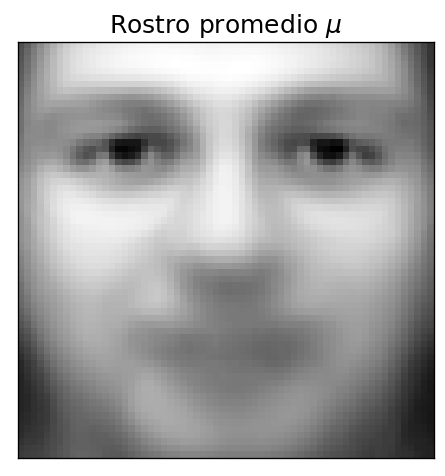

In [5]:
X_mean = X.mean(axis=0)          # un promedio por píxel: vector de largo p

plt.figure(figsize=(4.5, 4.5))
plt.imshow(X_mean.reshape(h, w), cmap='gray')
plt.title('Rostro promedio $\\mu$', fontsize=15)
plt.xticks(())
plt.yticks(())
plt.show()

### Para discutir: qué queda al restar $\mu$

> **¿Por qué el promedio de 400 caras distintas se sigue viendo como una cara?**

> **¿Qué información queda en una imagen después de restarle $\mu$?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p>Porque todas las caras comparten la misma estructura gruesa: ojos más o menos donde van, nariz en el
centro, boca en la parte inferior, fondo oscuro. Al promediar, eso se refuerza y lo idiosincrásico se cancela. Por eso el
rostro promedio se ve como una cara <b>borrosa</b>: es lo que <i>todas</i> tienen en común, y justamente por
eso no sirve para distinguir a nadie.</p>
<p>Al restarlo, lo que queda en cada fila es <b>en qué se diferencia esa foto del rostro típico</b>:
exactamente la información que necesitamos para distinguir personas.</p>
</details>

$$
X_c = X - \mu
$$

Por eso centrar no es un detalle técnico: es el paso que define de qué van a hablar las *eigenfaces*.

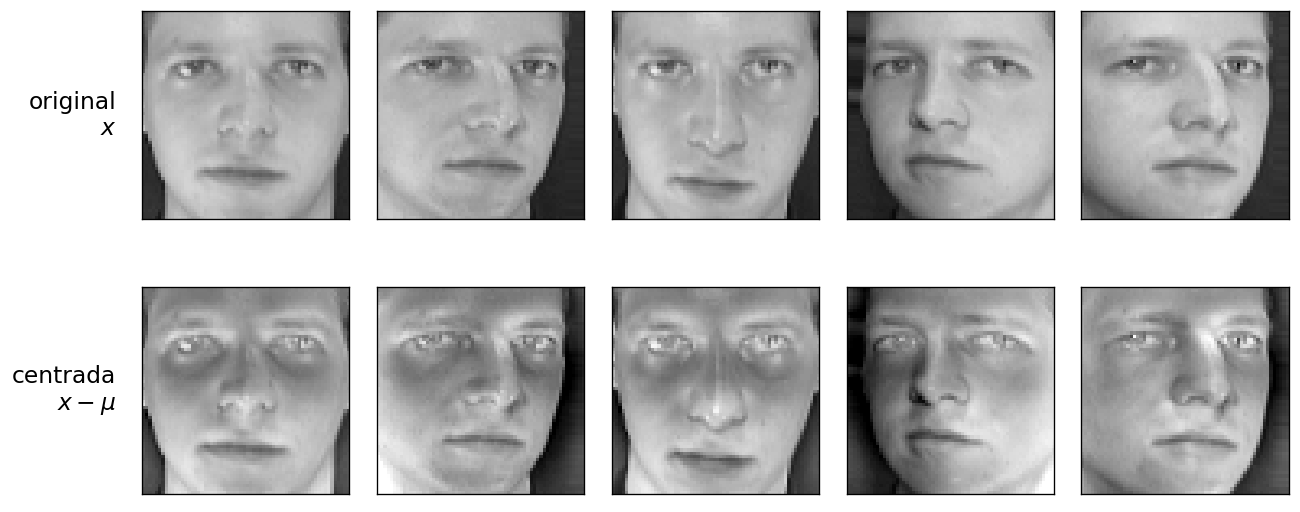

In [6]:
X_centered = X - X_mean          # cada fila: diferencia respecto al rostro promedio

# Arriba las originales, abajo las centradas.
# En las centradas hay valores negativos: el gris medio es el "cero".
m = np.percentile(np.abs(X_centered[:5]), 99)    # escala simétrica alrededor de 0

fig, axes = plt.subplots(2, 5, figsize=(11, 5),
                         subplot_kw={'xticks': [], 'yticks': []})
for j in range(5):
    axes[0, j].imshow(X[j].reshape(h, w), cmap='gray', vmin=0, vmax=1)
    axes[1, j].imshow(X_centered[j].reshape(h, w), cmap='gray', vmin=-m, vmax=m)
axes[0, 0].set_ylabel('original\n$x$', fontsize=14, rotation=0, ha='right', va='center', labelpad=12)
axes[1, 0].set_ylabel('centrada\n$x - \\mu$', fontsize=14, rotation=0, ha='right', va='center', labelpad=12)
plt.tight_layout()
plt.show()

## Pregunta 4

> Antes de calcular PCA, **¿siempre debemos centrar? ¿Siempre debemos estandarizar?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p><b>Centrar: prácticamente siempre.</b> Es lo que hace que PCA hable de variación <i>alrededor del
promedio</i>. Sin centrar, la primera dirección se ``consume" apuntando a dónde está la nube de datos.</p>
<p><b>Estandarizar: depende.</b> Es útil cuando las variables están en escalas o unidades distintas, y puede
ser contraproducente cuando ya están en la misma escala. Es una decisión, y es importante pensarla y justificarla. Generalmente las variables están en escalas o unidades distintas y por lo tanto el software suele traer la opción para hacerlo.</p>
</details>



## Centrar vs. estandarizar

### Centrar

$$
X_c = X - \mu
$$

Restamos la media de cada columna. Con esto, PCA/SVD describen **variaciones alrededor de la observación promedio**. En imágenes, $\mu$ será el **rostro promedio** y $X_c$ contendrá *en qué se diferencia cada cara del rostro típico*.

Sin centrar, la primera dirección tiende a apuntar hacia dónde está la nube de puntos (el promedio), no hacia dónde **varía**.

### Estandarizar

$$
\tilde{x}_j = \frac{x_j - \mu_j}{s_j}
$$


Además de centrar, dividimos cada variable por su desviación estándar. Con esto, variables medidas en **escalas distintas** se vuelven comparables.

En Olivetti todos los píxeles ya están medidos en la misma escala de intensidad. Por eso aquí la pregunta no es automática: **¿queremos realmente dar a cada píxel la misma varianza?**


### La pregunta que aparece en el Taller 2

> Si cada columna de nuestra matriz es un **píxel** y todos los píxeles están medidos en la **misma escala de intensidad**, ¿tiene sentido dividir cada píxel por su propia desviación estándar?

<details>
<summary><b>Pistas</b> (la decisión es suya: va en el taller)</summary>
<br>
<p><b>A favor de NO estandarizar:</b> todos los píxeles ya están en la misma escala de intensidad, así que el
problema que acabamos de mencionar —una variable que domina por sus unidades— no existe aquí. Además, dividir por
$\sigma_j$ le da el mismo peso a un píxel de una esquina oscura que casi no varía entre fotos que a un píxel de la
zona de los ojos: amplifica ruido.</p>
<p><b>A favor de estandarizar:</b> si hubiera zonas sistemáticamente sobreexpuestas o sensores con ganancias
distintas, igualar la escala podría evitar que unas pocas regiones muy brillantes dominen las primeras
direcciones.</p>
<p><b>Lo que se califica</b> no es cuál eligieron, sino que la decisión sea explícita y esté argumentada con
el significado de las variables — y que sean consistentes con ella en todo el análisis.</p>
</details>

## De las caras centradas a las *eigenfaces*

### SVD (repaso)

La idea de PCA es buscar direcciones de máxima varianza.

La **descomposición en valores singulares** (*singular value decomposition*, **SVD**) es el resultado de álgebra
lineal que nos permite obtener esas direcciones.

**Teorema.** *Toda* matriz real $A \in \mathbb{R}^{n\times p}$ (cualquiera: no necesita ser
cuadrada, ni invertible, ni simétrica, ni estar centrada) se puede factorizar como

$$
A \;=\; U\,\Sigma\,V^\top
$$

donde

- $U$, $n \times k$, columnas **ortonormales**: perpendiculares entre sí y de norma 1
- $\Sigma$, $k \times k$, **diagonal**, con $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_k \geq 0$
- $V$, $p \times k$, también con columnas **ortonormales**

Los $\sigma_j$ son los **valores singulares**. (Ojo con el símbolo: aquí $\sigma_j$ es un valor singular de la matriz, no la desviación estándar de la columna $j$ que usamos al estandarizar.) Aquí $k = \min(n,p)$: es la versión **reducida**
o *delgada*, la que calcula `full_matrices=False` y la que usaremos siempre. Si la matriz tiene
rango $r < k$, los últimos $k-r$ valores singulares son cero.

Ojo con lo que **no** dice el teorema: no supone nada sobre los datos. La SVD no es un modelo ni un método estadístico, es una **identidad algebraica** que siempre existe.



## La SVD de nuestra matriz de datos

En el taller vamos a aplicar la SVD a la matriz de datos **centrados**:

$$
\underbrace{X_c}_{n \times p} \quad\text{con}\quad
\begin{cases}
\text{filas} = \text{imágenes / rostros} & (n) \\
\text{columnas} = \text{píxeles} & (p)
\end{cases}
$$


Ya tenemos $X_c$: cada fila dice **cómo se diferencia una cara del rostro promedio**. Ahora necesitamos aprender direcciones comunes de variación.

La SVD nos da exactamente esa descomposición:

$$
X_c = U\,\Sigma\,V^\top.
$$

En nuestro problema, la lectura práctica es:

- las **filas de $V^\top$** tienen 4096 entradas y se pueden volver a dibujar como imágenes: serán las ***eigenfaces***;
- **cada fila de $U$** corresponde a una imagen y tiene una entrada por dirección: son las coordenadas de ese rostro **normalizadas** (cada columna de $U$ tiene norma 1);
- los valores de **$\Sigma$** ordenan esas direcciones de mayor a menor importancia y son la **escala** que devuelve esas coordenadas a las unidades de los datos;
- **$U\Sigma = X_cV$** contiene las **coordenadas (*scores*)** de cada rostro sobre esas direcciones.

No necesitamos memorizar las tres matrices antes de verlas. Calculemos la SVD y miremos primero qué aparece en $V^\top$.

In [7]:
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

print('X_centered:', X_centered.shape)
print('U         :', U.shape, '  -> una fila por imagen')
print('S         :', S.shape, '        -> valores singulares')
print('Vt        :', Vt.shape, ' -> una fila por dirección, con p entradas (¡una por píxel!)')

# Verificación: la SVD reproduce exactamente los datos centrados
print()
print('¿U @ diag(S) @ Vt reproduce X_centered?',
      np.allclose(U @ np.diag(S) @ Vt, X_centered, atol=1e-4))

X_centered: (400, 4096)
U         : (400, 400)   -> una fila por imagen
S         : (400,)         -> valores singulares
Vt        : (400, 4096)  -> una fila por dirección, con p entradas (¡una por píxel!)

¿U @ diag(S) @ Vt reproduce X_centered? True


> **¿Por qué solo 400 direcciones, si cada imagen tiene 4096 píxeles?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p>Porque con $n$ observaciones no se pueden aprender más de $\min(n, p)$ direcciones, y al centrar se pierde
una más: el máximo es $\min(n-1,\,p)$. Con 400 fotos centradas son <b>399</b> (el valor singular número 400
sale prácticamente cero).</p>
<p>Esto importa para el taller: <b>su grilla de $K$ tiene un techo duro en el número de imágenes de
entrenamiento</b>, no en el número de píxeles.</p>
</details>

## Visualizar las *eigenfaces*

Cada fila de `Vt` tiene $p$ entradas, una por píxel. Así que podemos redibujarla con la forma de una cara:

```python
eigenfaces = Vt
eigenfaces[i].reshape(h, w)
```

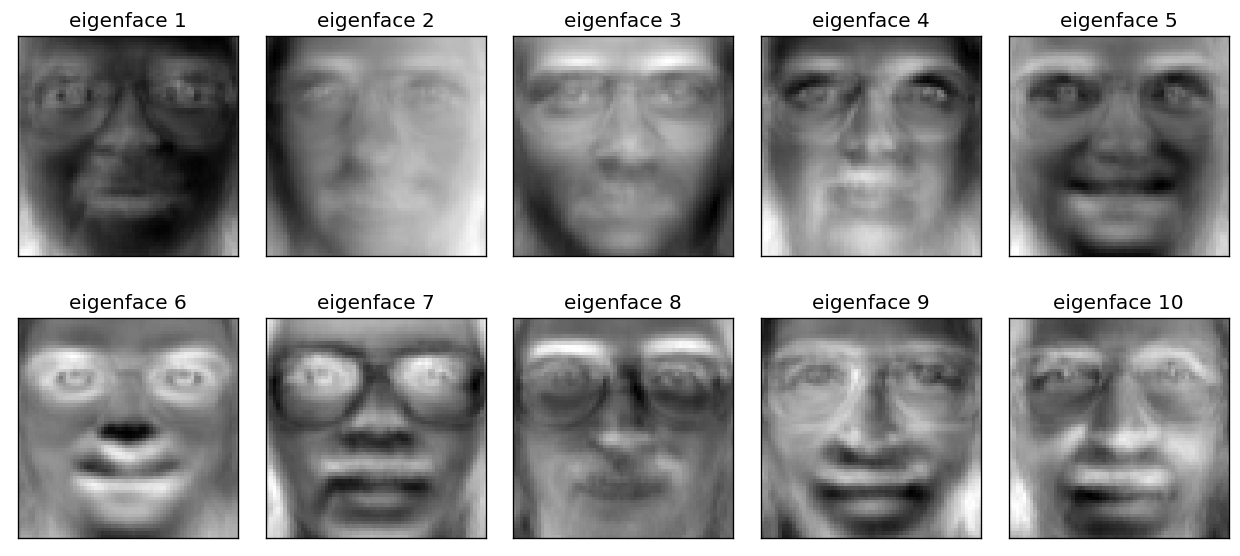

In [8]:
eigenfaces = Vt                   # cada fila es una dirección en el espacio de píxeles

mostrar_caras(eigenfaces[:10],
              titulos=['eigenface {}'.format(i + 1) for i in range(10)],
              n_col=5, alto_panel=2.5, ancho_panel=2.1)

### Una *eigenface* no es una persona

> **¿Una *eigenface* es la cara de una persona?**

> **¿Qué patrones parecen capturar las primeras? ¿Iluminación, orientación, contraste, gafas, posición de los ojos?**

> **¿Cómo le explicarían a un cliente qué es una *eigenface*, sin usar álgebra lineal?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
    
<p><b>No es una persona.</b> Es un <b>patrón de variación</b> compartido por muchas imágenes: "esta foto está
más iluminada por la izquierda", "esta cara es más ancha", "aquí hay sombra bajo los ojos". Cada rostro real
se arma como el rostro promedio <b>más</b> una mezcla de estos patrones.</p>
<p><b>Para el cliente, sin matemáticas:</b> Las <i>eigenfaces</i> son como plantillas de características faciales. No pertenecen a ninguna persona en particular; representan patrones que aparecen, en mayor o menor medida, en muchas caras. Combinando varias de estas plantillas, podemos aproximar o reconstruir el rostro de una persona concreta.</p>


$$
x \;\approx\; \mu + z_1 \cdot \textit{eigenface}_1 + z_2 \cdot \textit{eigenface}_2 + \cdots
$$

> *Detalle técnico:* el signo de cada *eigenface* es arbitrario, igual que el de un vector propio. Si multiplican una por $-1$ obtienen exactamente la misma dirección, con los claros y oscuros invertidos. No lean nada en cuál mitad salió clara.
    
    </details>

Este es el cambio de base del que hablamos arriba. Las *eigenfaces* que acabamos de dibujar son las nuevas piezas comunes $v_1,v_2,\ldots$. Para cualquier rostro:

$$
x \approx \mu + z_1v_1+z_2v_2+\cdots+z_Kv_K.
$$

Aquí hay dos objetos distintos:

- **direcciones $v_j$:** son las mismas *eigenfaces* para todas las personas;
- **coordenadas $z_j$:** cambian de una foto a otra y dicen cuánto necesita esa cara de cada patrón.

Y ahora es evidente por qué podemos dibujar un componente: cada $v_j$ tiene **una entrada por píxel**, igual que una cara original.


### ¿Y si no hubiéramos centrado?

Retomemos la pregunta sobre **centrar**, ahora con las caras en la mano. Calculemos la SVD
sobre las imágenes **crudas** (sin restar el rostro promedio) y miremos su primera dirección.

sin centrar : sigma_1 =  717.2   ->  95.4% de la "varianza"
centrada    : sigma_1 =   86.7   ->  23.8% de la varianza

correlación entre v1 (sin centrar) y el rostro promedio: 0.9998


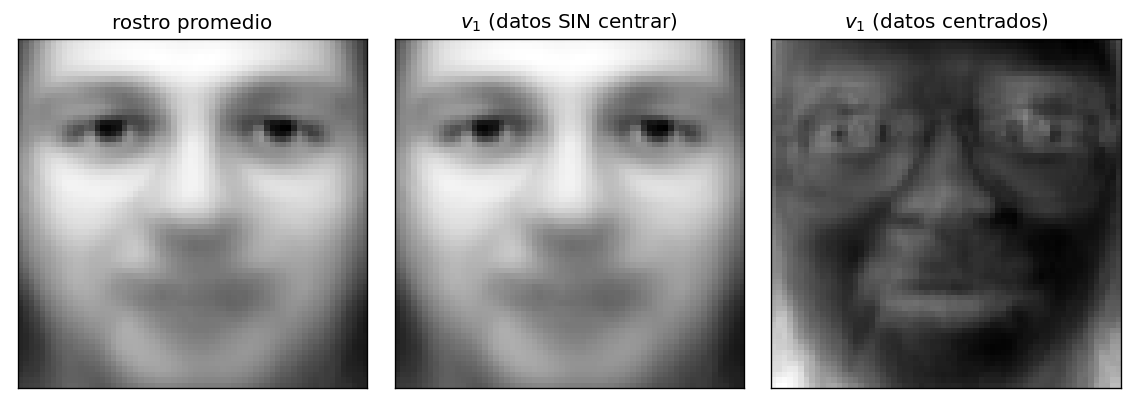

In [9]:
U0, S0, Vt0 = np.linalg.svd(X, full_matrices=False)      # SVD SIN centrar

# El signo de un vector singular es arbitrario: lo volteamos para poder compararlo
v1_sin_centrar = Vt0[0]
if np.corrcoef(v1_sin_centrar, X_mean)[0, 1] < 0:
    v1_sin_centrar = -v1_sin_centrar

print('sin centrar : sigma_1 = {:6.1f}   ->  {:4.1f}% de la "varianza"'.format(
    S0[0], 100 * S0[0] ** 2 / np.sum(S0 ** 2)))
print('centrada    : sigma_1 = {:6.1f}   ->  {:4.1f}% de la varianza'.format(
    S[0], 100 * S[0] ** 2 / np.sum(S ** 2)))
print()
print('correlación entre v1 (sin centrar) y el rostro promedio:',
      round(abs(np.corrcoef(Vt0[0], X_mean)[0, 1]), 4))

mostrar_caras([X_mean, v1_sin_centrar, Vt[0]],
              titulos=['rostro promedio', '$v_1$ (datos SIN centrar)', '$v_1$ (datos centrados)'],
              n_col=3, alto_panel=3.6, ancho_panel=3.2)

### Sin centrar, la primera dirección es el rostro promedio

La primera dirección de la SVD sin centrar **es**, para todos los efectos prácticos, el rostro promedio (se correlacionan en $0.9998$) y
se lleva el **95.4%** de la "varianza". No es una *eigenface*: no describe ninguna variación,
describe el punto de partida. Gastamos la primera dirección (y casi todo el presupuesto de la consultoría) en
algo que ya sabíamos.

Al centrar, ese 95.4% desaparece: $\sigma_1$ cae de $717$ a $87$ y la primera dirección pasa a ser
un patrón de variación de verdad. Los valores singulares vuelven a medir variación alrededor del
rostro típico, y la curva de varianza acumulada que vamos a graficar en un minuto significa lo
que decimos que significa.

Esto es parte de la pregunta del **Paso 2 del Taller 2**: centrar no es un trámite previo a la SVD, es lo que hace que las *eigenfaces* y la varianza explicada sean interpretables.

## ¿Por qué esto sigue siendo PCA?

Con los datos centrados, la matriz de covarianzas es proporcional a $X_c^\top X_c$. Si

$$
X_c=U\Sigma V^\top,
$$

entonces

$$
X_c^\top X_c = V\Sigma^2V^\top.
$$

Por eso las columnas de $V$ son justamente las direcciones principales de PCA, y $\sigma_j^2/(n-1)$ corresponde a la varianza de cada dirección.

$$
\boxed{\text{PCA sobre datos centrados puede calcularse con una SVD de }X_c}
$$

La derivación completa y la verificación numérica están en el material de la semana.

# 3. ¿Cuántas *eigenfaces* necesitamos?

Esta es la clave del Taller, elegir las eigenfaces, que implica elegir la dimensión $K$.

Miremos qué información tenemos para tomarla.

## Valores singulares y varianza explicada

$$
\text{proporción de varianza de la dirección } j = \frac{\sigma_j^2}{\sum_{\ell=1}^{k} \sigma_\ell^2}
$$

Ojo: la suma del denominador va sobre **todas** las direcciones ($\ell = 1,\ldots,k$), no sobre las $K$ que decidamos retener.

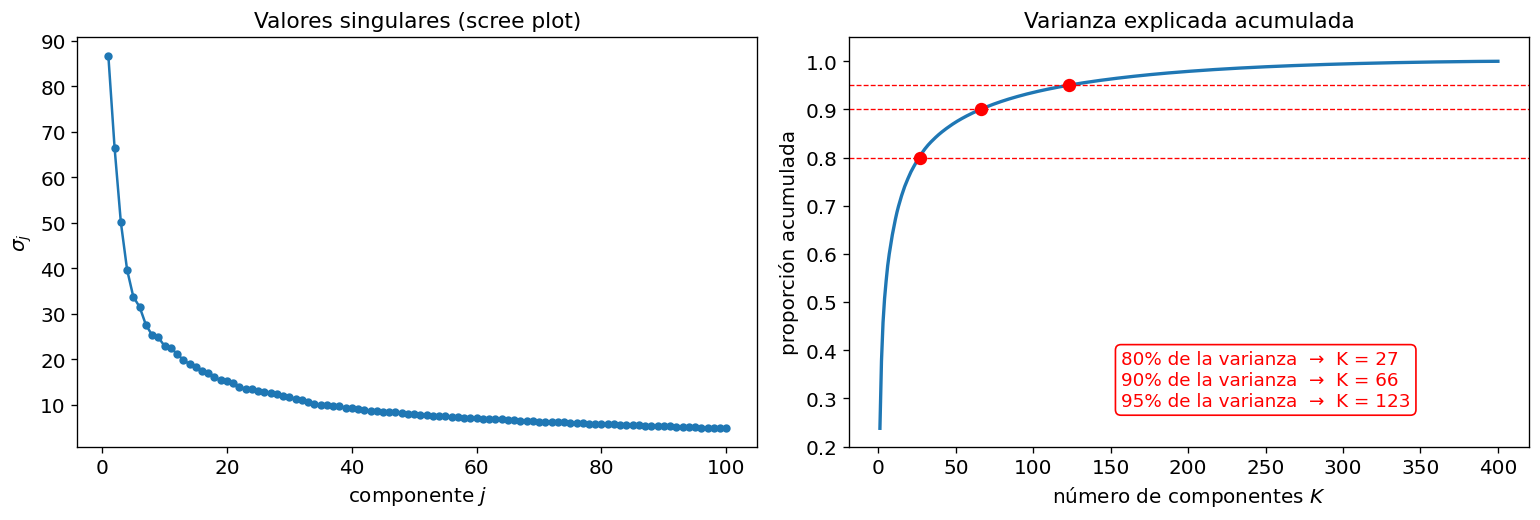

In [10]:
explained_variance_ratio = S ** 2 / np.sum(S ** 2)
cumulative_variance = np.cumsum(explained_variance_ratio)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(range(1, 101), S[:100], 'o-', ms=4)
ax[0].set_title('Valores singulares (scree plot)')
ax[0].set_xlabel('componente $j$')
ax[0].set_ylabel('$\\sigma_j$')

ax[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, lw=2)

etiquetas = []
for umbral in [0.80, 0.90, 0.95]:
    K_umbral = int(np.searchsorted(cumulative_variance, umbral) + 1)
    ax[1].axhline(umbral, color='red', ls='--', lw=0.8)
    ax[1].plot([K_umbral], [umbral], 'o', color='red', ms=7)
    etiquetas.append('{:.0f}% de la varianza  →  K = {}'.format(100 * umbral, K_umbral))

ax[1].text(0.40, 0.10, '\n'.join(etiquetas), transform=ax[1].transAxes,
           color='red', fontsize=11,
           bbox=dict(boxstyle='round', facecolor='white', edgecolor='red'))
ax[1].set_ylim(0.2, 1.05)
ax[1].set_title('Varianza explicada acumulada')
ax[1].set_xlabel('número de componentes $K$')
ax[1].set_ylabel('proporción acumulada')

plt.tight_layout()
plt.show()

In [11]:
# ¿Cuántos componentes hacen falta para 80%, 90% y 95%?
for umbral in [0.80, 0.90, 0.95]:
    K_necesario = int(np.searchsorted(cumulative_variance, umbral) + 1)
    print('{:.0f}% de la varianza -> K = {:4d}   (de {} píxeles)'.format(
        100 * umbral, K_necesario, p))

80% de la varianza -> K =   27   (de 4096 píxeles)
90% de la varianza -> K =   66   (de 4096 píxeles)
95% de la varianza -> K =  123   (de 4096 píxeles)


### Para discutir: varianza explicada no es *accuracy*

> **Un rostro tiene miles de píxeles, pero unas pocas decenas de direcciones capturan el 90% de la varianza. ¿Qué nos dice eso sobre los píxeles de un rostro?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p>Que son <b>enormemente redundantes</b>: los píxeles vecinos se parecen y las caras comparten estructura.
La dimensión "efectiva" del problema es mucho menor que $p$. Eso es justamente lo que hace viable el sistema
del taller: si hicieran falta los 4096 números, no habría nada que comprimir.</p>
</details>

>  **Y la pregunta clave para el taller:**
>
> **¿90% de varianza explicada significa 90% de *accuracy* en la clasificación?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p><b>No.</b> Son cosas distintas:</p>
<ul>
<li>la <b>varianza explicada</b> dice qué tan bien podemos <b>reconstruir / representar</b> la matriz $X$;</li>
<li>el <b><i>accuracy</i></b> (o <i>recall</i>, o $F_1$) dice qué tan bien resolvemos una <b>tarea predictiva
posterior</b>.</li>
</ul>
<p>Nada garantiza que la información que más varía sea la que más sirve para <b>distinguir a una persona</b>.
Puede que la dirección que más varianza captura sea... la iluminación de la sala.</p>
</details>

## Reconstrucciones con distintos $K$

La **SVD truncada** se queda con las primeras $K$ direcciones:

$$
X_c \;\approx\; U_K \Sigma_K V_K^\top
\qquad\Longrightarrow\qquad
\hat{X}_K = U_K \Sigma_K V_K^\top + \mu
$$

y, observación por observación:

$$
x \;\approx\; \mu + z_1 v_1 + \cdots + z_K v_K
$$

**No olviden volver a sumar el rostro promedio**: la SVD se hizo sobre datos centrados.

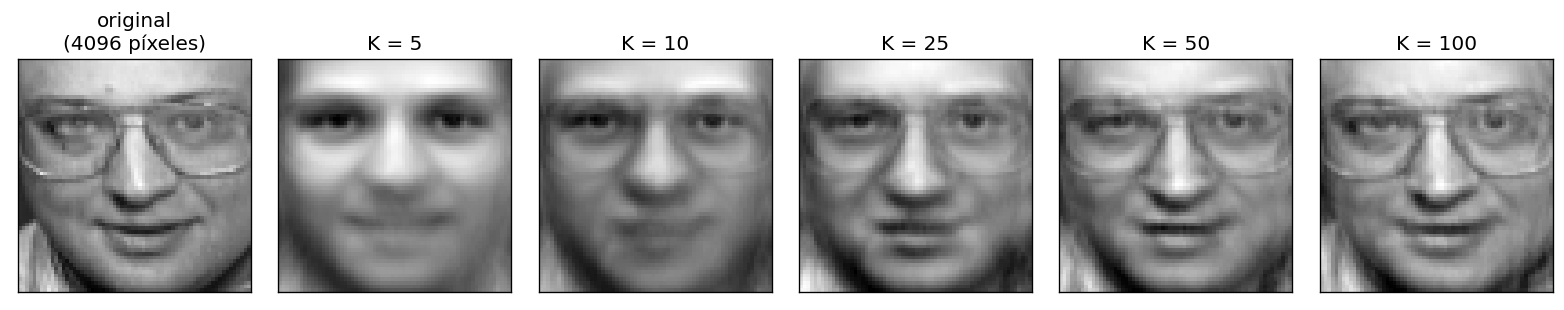

In [12]:
def reconstruir(K):
    # Reconstrucción truncada de TODAS las imágenes con K componentes
    X_hat_centered = U[:, :K] @ np.diag(S[:K]) @ Vt[:K, :]
    return X_hat_centered + X_mean


i = 300                                   # una cara cualquiera
lista_K = [5, 10, 25, 50, 100]

imagenes = [X[i]] + [reconstruir(K)[i] for K in lista_K]
titulos = ['original\n({} píxeles)'.format(p)] + ['K = {}'.format(K) for K in lista_K]

mostrar_caras(imagenes, titulos=titulos, n_col=6, alto_panel=3.2, ancho_panel=2.2)

Notemos que la imagen original necesita $p = h \times w$ números (4096 en el caso de Olivetti). Una vez que la base de *eigenfaces* ya está **aprendida y guardada**, cada rostro nuevo se describe con solo $K$ dimensiones. Logramos comprimir y reducir la dimensión.

In [13]:
filas = []
for K in [5, 10, 25, 50, 100, 200]:
    X_hat = reconstruir(K)
    rmse = np.sqrt(np.mean((X_hat - X) ** 2))
    filas.append({
        'K': K,
        '% varianza capturada': round(100 * cumulative_variance[K - 1], 1),
        'números por rostro': K,
        '% del tamaño original': round(100 * K / p, 2),
        'error de reconstrucción (RMSE)': round(rmse, 4),
    })

tabla = pd.DataFrame(filas).set_index('K')
print('Una imagen original requiere p =', p, 'números.\n')
tabla

Una imagen original requiere p = 4096 números.



,% varianza capturada,números por rostro,% del tamaño original,error de reconstrucción (RMSE)
K,,,,
5,54.4,5,0.12,0.0938
10,65.6,10,0.24,0.0814
25,79.3,25,0.61,0.0631
50,87.4,50,1.22,0.0493
100,93.5,100,2.44,0.0353
200,97.9,200,4.88,0.0201



> **¿El mejor $K$ es aquel para el cual la cara se ve perfectamente reconocible para un humano?**

<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p><b>No necesariamente.</b> Al cliente del Taller 2 no le importa que la foto se vea bonita en una pantalla:
le importa que las <b>coordenadas preserven suficiente información para verificar identidades
correctamente</b>. Son dos criterios distintos y pueden apuntar a valores de $K$ distintos.</p>
<p>El $K$ que recomienden tiene que balancear cuatro cosas: <b>almacenamiento</b> (costo marginal por
rostro), <b>representación</b> (varianza capturada y calidad de reconstrucción), <b>desempeño
predictivo</b> (¿verifica bien la identidad?) y <b>consecuencias de los errores</b> (no todos cuestan lo
mismo).</p>
</details>

$$
\text{buena reconstrucción} \;\neq\; \text{necesariamente mejor clasificación}
$$

# 4. Sistema de reconocimiento facial

Ya tenemos las *eigenfaces*. Ahora queremos usar esas direcciones para representar cada rostro con pocos números.

## De una imagen a $K$ números

Recordemos que la SVD de las imágenes centradas es

$$
X_c = U\Sigma V^\top.
$$

Las columnas de $V$ son las *eigenfaces*. Para obtener las **coordenadas de cada imagen sobre esas direcciones**, proyectamos:

$$
Z = X_cV.
$$

Sustituyendo la SVD:

$$
Z
= U\Sigma V^\top V
= U\Sigma,
$$

porque las columnas de $V$ son ortonormales y, por tanto,

$$
V^\top V = I.
$$

Así,

$$
Z=X_cV=U\Sigma
$$

son exactamente las **coordenadas (*scores*) de las imágenes en la base de *eigenfaces***.

Cada fila de $Z$ representa una imagen:

$$
x^{(i)}
\quad\longrightarrow\quad
(z_{i1},z_{i2},\ldots,z_{ik}),
$$

donde $z_{ij}$ indica cuánto de la *eigenface* $j$ aparece en la imagen $i$.

Si usamos solamente las primeras $K$ *eigenfaces*:

$$
Z_K=X_cV_K,
$$

cada imagen queda representada por solo $K$ números, que serán las variables que recibe el clasificador.



In [14]:
K = 50

Z_K = X_centered @ Vt[:K].T              # Z_K = X_c V_K   -> (n x K)

print('Z_K:', Z_K.shape, ' -> cada imagen quedó descrita por', K, 'números')
print()
print('¿X_c V_K coincide con las primeras K columnas de U*S?',
      np.allclose(Z_K, (U * S)[:, :K], atol=1e-4))
print()
pd.DataFrame(Z_K[:5, :6],
             columns=['z{}'.format(j + 1) for j in range(6)],
             index=['imagen {}'.format(i + 1) for i in range(5)]).round(2)

Z_K: (400, 50)  -> cada imagen quedó descrita por 50 números

¿X_c V_K coincide con las primeras K columnas de U*S? True



,z1,z2,z3,z4,z5,z6
imagen 1,-6.43,-0.70,-1.43,1.28,-2.56,0.95
imagen 2,-1.08,-6.70,1.84,5.08,-0.73,1.76
imagen 3,-5.29,-1.54,0.23,1.11,-2.64,1.67
imagen 4,-4.25,11.33,0.09,-0.22,-1.41,0.83
imagen 5,-3.96,-3.29,3.65,3.55,-2.79,1.82


Entonces, resumiendo, el flujo que tenemos que seguir será:

```text
      Imagen
      ↓ centrar
      x - μ
      ↓ proyectar sobre K eigenfaces
      (z1, z2, ..., zK)
      ↓
      clasificador logístico
      ↓
      Pr(Y = 1 | z) = probabilidad de ser el usuario
      ↓ comparar con el punto de corte c
      identidad: sí / no
```


## El clasificador no devuelve una identidad, sino una probabilidad

Recordemos de aprendizaje supervisado, que una regresión logística no modela directamente la clase, sino la **probabilidad condicional**

$$
\Pr(Y = 1 \mid Z)
$$

es decir, la probabilidad de que la observación pertenezca a la clase positiva **dado lo que observamos de ella**. En nuestro caso, lo que observamos de la imagen $i$ son sus $K$ coordenadas $z^{(i)} = (z_{i1},\ldots,z_{iK})$.

Lo que el modelo estima es el **logit** de esa probabilidad, que es lineal en las coordenadas:

$$
\log \frac{\Pr(Y = 1 \mid z^{(i)})}{1 - \Pr(Y = 1 \mid z^{(i)})} \;=\; \beta_0 + \beta_1 z_{i1} + \beta_2 z_{i2} + \cdots + \beta_K z_{iK}
$$

Despejando se obtiene la probabilidad estimada, que por construcción siempre queda entre 0 y 1:

$$
\Pr(Y = 1 \mid z^{(i)}) \;=\; \frac{1}{1 + e^{-(\beta_0 + \beta_1 z_{i1} + \cdots + \beta_K z_{iK})}}
$$

**La decisión es un segundo paso, distinto del primero.** Para convertir esa probabilidad en un "pase" o "no pase" hace falta un **punto de corte** $c$:

$$
\hat y_i =
\begin{cases}
1 & \text{si } \Pr(Y = 1 \mid z^{(i)}) \geq c \\
0 & \text{en otro caso}
\end{cases}
$$

Por defecto $c = 0.5$, y es exactamente lo que aplica `predict()` de scikit-learn sin avisarnos. Pero nada obliga a usar ese valor:

- **bajar $c$** acepta más intentos: sube el *recall* y baja la precisión;
- **subir $c$** es más exigente: sube la precisión y baja el *recall*.

Es decir, $c$ no es una decisión estadística, sino **del cliente**: es la palanca concreta con la que se ejecuta la asimetría entre los dos errores que discutiremos al cerrar la sesión, en **Los dos errores no cuestan lo mismo**.

## ¡Cuidado con el *leakage*!

Supongamos que partimos la base en **entrenamiento** y **prueba** para evaluar honestamente el sistema.

> **¿Con cuáles imágenes debemos calcular el rostro promedio $\mu$ y las *eigenfaces* $V$?**
>
> - **a)** con todas las imágenes, antes de partir
> - **b)** solo con las de entrenamiento


<details>
<summary><b>Ver respuesta</b></summary>
<br>
<p><b>(b), solo con las de entrenamiento.</b> El rostro promedio y las <i>eigenfaces</i> son parte del
<b>modelo</b>, no de los datos: son cosas que <i>aprendemos</i>. Si las aprendemos usando también las
imágenes de prueba, esas imágenes participan indirectamente en el entrenamiento y la evaluación deja de
simular lo que pasaría con datos nuevos.</p>
<p>Regla práctica: en el torniquete, la cara que llega <b>no existía</b> cuando se construyó el sistema. Su
evaluación tiene que reproducir esa situación.</p>
</details>

### El *pipeline* correcto

```text
TRAIN                                TEST
  ↓                                    ↓
calcular μ                     restar LA MEDIA APRENDIDA EN TRAIN
  ↓                                    ↓
centrar                        proyectar usando LAS EIGENFACES
  ↓                              APRENDIDAS EN TRAIN
aprender eigenfaces (SVD)              ↓
  ↓                              clasificador (ya entrenado)
proyectar                              ↓
  ↓                              evaluar
entrenar clasificador
```

**Nunca** se vuelven a aprender $\mu$, la SVD ni las *eigenfaces* usando el conjunto de prueba.

> Si usamos las imágenes de prueba para aprender la representación antes de evaluar, la información del conjunto de prueba participa indirectamente en el entrenamiento: la evaluación deja de simular datos nuevos y el desempeño reportado se ve mejor de lo que realmente es.



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Tarea binaria: ¿esta foto es de alguno de los empleados registrados?
registrados = [10, 11, 12, 13, 14]
y_bin = np.isin(y, registrados).astype(int)

# 80/20 estratificado. Estos parámetros (random_state, solver) son los que EXIGE la guía del taller
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=10101, stratify=y_bin)

# --- Todo se aprende con TRAIN ------------------------------------------
mu_train = X_train.mean(axis=0)
U_tr, S_tr, Vt_tr = np.linalg.svd(X_train - mu_train, full_matrices=False)

K = 50
Z_train = (X_train - mu_train) @ Vt_tr[:K].T     # proyectar train
Z_test = (X_test - mu_train) @ Vt_tr[:K].T       # ¡media y base de TRAIN!

clf = LogisticRegression(solver='sag', random_state=10101, max_iter=1000)
clf.fit(Z_train, y_train)
y_pred = clf.predict(Z_test)

print('prueba:', len(y_test), 'imágenes, de las cuales', int(y_test.sum()), 'son de personas registradas')
aciertos = int((y_pred == y_test).sum())
negativos = int((y_test == 0).sum())
print('accuracy del modelo    : {}/{} = {:.3f}'.format(
    aciertos, len(y_test), aciertos / len(y_test)))
print('accuracy de decir "no" : {}/{} = {:.3f}   <- referencia ingenua'.format(
    negativos, len(y_test), negativos / len(y_test)))
print()
print('Matriz de confusión (filas = verdad, columnas = predicción):')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred,
                            target_names=['no registrado', 'registrado'], digits=3))

prueba: 80 imágenes, de las cuales 10 son de personas registradas
accuracy del modelo    : 77/80 = 0.963
accuracy de decir "no" : 70/80 = 0.875   <- referencia ingenua

Matriz de confusión (filas = verdad, columnas = predicción):
[[70  0]
 [ 3  7]]

               precision    recall  f1-score   support

no registrado      0.959     1.000     0.979        70
   registrado      1.000     0.700     0.824        10

     accuracy                          0.963        80
    macro avg      0.979     0.850     0.901        80
 weighted avg      0.964     0.963     0.960        80



## La matriz de confusión: cuatro casillas, no una

Cualquier clasificador binario produce cuatro resultados posibles, según lo que era verdad y lo que predijo:

|  | predice **0** (rechaza) | predice **1** (acepta) |
| --- | :---: | :---: |
| **realidad 0** (no es el usuario) | $\mathrm{VN}$ | $\mathrm{FP}$ |
| **realidad 1** (sí es el usuario) | $\mathrm{FN}$ | $\mathrm{VP}$ |

Leídas en el torniquete:

- $\mathrm{VP}$  **verdadero positivo**: es el empleado y el sistema lo deja pasar. Acierto.
- $\mathrm{VN}$  **verdadero negativo**: es un extraño y el sistema lo rechaza. Acierto.
- $\mathrm{FP}$  **falso positivo**: es un extraño y el sistema **lo deja pasar**.
- $\mathrm{FN}$  **falso negativo**: es el empleado y el sistema **lo bloquea**.

La diagonal son los aciertos; las otras dos casillas son los **dos tipos de error**, y no cuestan lo mismo (volvemos a eso en **Los dos errores no cuestan lo mismo**).

En la corrida de arriba: $\mathrm{VN} = 70$, $\mathrm{FP} = 0$, $\mathrm{FN} = 3$, $\mathrm{VP} = 7$.

## Matriz de confusión


$$
\begin{array}{c|cc}
& \text{Predicción 0} & \text{Predicción 1} \\
\hline
\text{Verdad 0} & \text{VN }(70) & \text{FP }(0) \\
\text{Verdad 1} & \text{FN }(3) & \text{VP }(7)
\end{array}
$$



## Las cuatro métricas salen de esas casillas

$$
\begin{aligned}
\text{accuracy} &= \frac{\mathrm{VN} + \mathrm{VP}}{\mathrm{VN} + \mathrm{FP} + \mathrm{FN} + \mathrm{VP}} \\
\text{precisión} &= \frac{\mathrm{VP}}{\mathrm{FP} + \mathrm{VP}} \\
\text{recall} &= \frac{\mathrm{VP}}{\mathrm{FN} + \mathrm{VP}} \\
F_1 &= \frac{2 \cdot \text{precisión} \cdot \text{recall}}{\text{precisión} + \text{recall}}
\end{aligned}
$$

Lo que cambia de una métrica a otra es el **universo sobre el que estamos haciendo la pregunta**:

* ***accuracy***: *de todas las decisiones que tomé, ¿qué fracción fue correcta?* Mira las cuatro casillas de la matriz. Las decisiones correctas están en la diagonal: $\mathrm{VN}$ y $\mathrm{VP}$. Como su denominador es el total, una clase muy frecuente puede dominar esta métrica.
* **precisión**: *de los que dejé pasar, ¿qué fracción era realmente el usuario?* Mira solo la **columna Predicción 1**: $\mathrm{FP}$ y $\mathrm{VP}$. La castigan los $\mathrm{FP}$.
* ***recall*** o sensibilidad: *de los que realmente eran el usuario, ¿a cuántos dejé pasar?* Mira solo la **fila Verdad 1**: $\mathrm{FN}$ y $\mathrm{VP}$. La castigan los $\mathrm{FN}$.
* **$F_1$**: combina **precisión** y ***recall*** mediante su media armónica. Solo es alta cuando ambas métricas son altas: si una cae mucho, $F_1$ también cae.

En general, precisión y *recall* compiten entre sí. Al mover el punto de corte $c$, podemos favorecer una a costa de la otra.

Con nuestros números, seguimos exactamente el mismo orden de lectura de la matriz:

$$
\begin{aligned}
\text{accuracy} &= \frac{70 + 7}{70 + 0 + 3 + 7} = \frac{77}{80} = 0.963 \\
\text{precisión} &= \frac{7}{0 + 7} = 1.000 \\
\text{recall} &= \frac{7}{3 + 7} = 0.700 \\
F_1 &= \frac{2 \cdot 1.000 \cdot 0.700}{1.000 + 0.700} = 0.824
\end{aligned}
$$

Las cuatro coinciden con el `classification_report` que imprime la celda de código del *pipeline*.


## Cómo leer este resultado

Con 50 números por rostro, el 1.2% de los píxeles originales, el modelo acierta **77 de las 80** imágenes de prueba (*accuracy* **0.963**). Suena
muy bien... hasta que miran la referencia ingenua: un sistema que respondiera **"no registrado" a todo**
sacaría **87.5%**, porque solo 10 de las 80 imágenes de prueba son de personas registradas.

Y la matriz de confusión cuenta la historia que el *accuracy* escondía:

- **0 falsos positivos**: nunca dejó entrar a un extraño (precisión $1.000$);
- **3 falsos negativos** de 10: bloqueó a 3 empleados legítimos en el torniquete (*recall* $0.700$).

Ese es exactamente el *trade-off* del que van a tener que hablarle al cliente, y un solo número no cuenta toda la historia.


## ¿Y si cambiamos $K$?

Hasta aquí usamos $K = 50$ porque sí. Pero elegir $K$ es **la** decisión del taller, así que hagamos lo que
el Paso 5 les va a pedir: repetir la evaluación para varios $K$ y mirar qué se mueve.

In [16]:
from sklearn.metrics import precision_score, recall_score

filas = []
for K in [2, 5, 10, 25, 50, 100]:
    Z_train_K = (X_train - mu_train) @ Vt_tr[:K].T   # misma media y misma base de TRAIN
    Z_test_K = (X_test - mu_train) @ Vt_tr[:K].T
    modelo = LogisticRegression(solver='sag', random_state=10101,
                                max_iter=1000).fit(Z_train_K, y_train)
    pred = modelo.predict(Z_test_K)
    filas.append({'K': K,
                  'accuracy': round(float(modelo.score(Z_test_K, y_test)), 3),
                  'precisión': round(float(precision_score(y_test, pred, zero_division=0)), 3),
                  'recall': round(float(recall_score(y_test, pred)), 3)})

print('referencia ingenua (decir "no" a todo): accuracy =', round(float(1 - y_test.mean()), 3))
pd.DataFrame(filas).set_index('K')

referencia ingenua (decir "no" a todo): accuracy = 0.875


,accuracy,precisión,recall
K,,,
2,0.875,0.000,0.0
5,0.875,0.000,0.0
10,0.838,0.200,0.1
25,0.938,0.778,0.7
50,0.963,1.000,0.7
100,0.975,1.000,0.8


### Lo que se mueve al subir $K$ es el *recall*

<details>
<summary><b>Ver lectura de la tabla</b></summary>
<br>
<p>Miremos las filas de $K = 2$ y $K = 5$: <b>accuracy $0.875$, exactamente igual a la referencia ingenua, de decir no a todo,
con <i>recall</i> $0.000$.</b> El modelo no reconoció a <i>ni una sola</i> persona registrada y aun así su
<i>accuracy</i> se ve respetable. En $K = 10$ el <i>accuracy</i> ($0.838$) queda incluso <b>por
debajo</b> de la referencia.</p>
<p>A medida que sube $K$, lo que se mueve de verdad es el <i>recall</i>
($0.00 \rightarrow 0.70 \rightarrow 0.80$), mucho más de lo que se mueve el <i>accuracy</i>
($0.875 \rightarrow 0.963 \rightarrow 0.975$). Traducido al torniquete: con más dimensiones el sistema
deja de bloquear empleados legítimos.</p>
</details>

Juntemos esta tabla con la de la sección anterior y tenemos la estructura del **ranking de configuraciones** que pide el taller: cuánto se guarda por rostro, cuánta varianza se captura, qué tan buena es la reconstrucción y **qué tan bien funciona**. Elegir $K$ implica leer esa tabla completa, no una sola columna.

> Ojo con dos cosas: aquí subir $K$ es muy "barato" porque Olivetti es pequeña y fácil, y además **está
> balanceada por identidad** (10 fotos por persona). Aun así, nuestra tarea binaria sí está desbalanceada:
> solo 5 de las 40 personas están registradas, o sea el 12.5% de las imágenes, y por eso la referencia
> ingenua es "solo" 87.5%.
> En el taller, con un único usuario piloto, la clase positiva será **poco frecuente** y esa referencia
> será alta: calcúlenla sobre su propia partición antes de mirar cualquier otra métrica.

# 5. Cómo conecta esto con el Taller 2


El caso: una empresa quiere reemplazar las tarjetas de acceso por **reconocimiento facial en los torniquetes**, con hardware barato y sin GPU. Ustedes deben recomendar si lanzar el piloto y, si sí, **con qué $K$ y con qué salvedades**.

## La elección de $K$

Todo lo que vimos hoy alimenta esa decisión:

| Evidencia | De dónde sale |
| --- | --- |
| Cuánto se guarda por rostro | $K$ frente a $p$ píxeles (costo marginal) |
| Qué tanto se representa | varianza acumulada y error de reconstrucción |
| Si la cara se reconoce | reconstrucciones visuales |
| Si el sistema **funciona** | desempeño del clasificador para varios $K$ |

Recuerden: **varianza explicada ≠ *accuracy***. La tabla de configuraciones ordena alternativas bajo criterios explícitos; no declara un ganador universal.

# Información de Sesión

In [17]:
import session_info

session_info.show(html=False)

-----
matplotlib          3.5.3
numpy               1.18.4
pandas              1.0.3
session_info        v1.0.1
sklearn             1.0.2
-----
IPython             7.34.0
jupyter_client      7.4.9
jupyter_core        4.12.0
jupyterlab          2.1.1
notebook            6.0.3
-----
Python 3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) [GCC 7.3.0]
Linux-6.5.0-1024-aws-x86_64-with-debian-buster-sid
-----
Session information updated at 2026-08-10 21:15
